In [1]:
import os
# os.chdir(os.path.dirname(os.path.abspath(__file__))) 
import open3d as o3d
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
def custom_draw_geometry_with_rotation(pcd):

    def rotate_view(vis):
        ctr = vis.get_view_control()
        ctr.rotate(3, 0, -2.5, 0)
        return False

    o3d.visualization.draw_geometries_with_animation_callback(pcd, rotate_view)
# pcd = o3d.io.read_point_cloud(pcd_path)
# pcd_path = "./data/Batch12_27DAS/plant11.ply"
# # pcd_path1 = "/home/sp-medicago/MEDICAGO_data/All_scan/Batch14/20220802/20220802124234/merge/merge_pcd_cam1.ply"
# pcd, _ = pcd.remove_statistical_outlier(nb_neighbors=14, std_ratio=0.8) #seems better
# pcd, _ = pcd.remove_radius_outlier(nb_points=20, radius=10)

# custom_draw_geometry_with_rotation(pcd)

In [3]:
def clean_pcd(pcd: o3d.geometry.PointCloud, nb_neighbors=10, std_ratio=0.4):
    pcd, _ = pcd.remove_statistical_outlier(nb_neighbors=10, std_ratio=0.4)
    pcd, _ = pcd.remove_radius_outlier(nb_points=20, radius=3)
    return pcd

In [4]:
def clean_pcd1(pcd: o3d.geometry.PointCloud, nb_neighbors=10, std_ratio=0.4):
    pcd, _ = pcd.remove_statistical_outlier(nb_neighbors=10, std_ratio=0.4)
    pcd, _ = pcd.remove_radius_outlier(nb_points=20, radius=10)
    return pcd

In [5]:
pcd = o3d.io.read_point_cloud('./data/sample_plant/whole_pointcloud.ply')
xyz = np.asarray(pcd.points)
rgb = np.asarray(pcd.colors)

rgb_new = np.expand_dims(rgb, axis=0)
rgb_new = (255 * rgb_new).astype(np.uint8)
hsv = cv2.cvtColor(rgb_new, cv2.COLOR_RGB2HSV)
mask = cv2.inRange(hsv, (35, 85, 85), (50, 240, 240))

green_xyz = xyz[mask[0].astype(bool)]
colors = rgb[mask[0].astype(bool)]

pcd_green = o3d.geometry.PointCloud()
pcd_green.points = o3d.utility.Vector3dVector(green_xyz)
pcd_green.colors = o3d.utility.Vector3dVector(colors)

# o3d.io.write_point_cloud('./data/sample_plant/green.ply', clean_pcd(pcd_green))
o3d.visualization.draw_geometries([pcd_green])

[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 


In [126]:

# Used for presentation IIIIMMMMMMPPPP
pcd = o3d.io.read_point_cloud('D:\programsX64\AnacondaFiles\Medicago-Code\plant_traits\data\Batch12_bg27DAS\plant1.ply')
xyz = np.asarray(pcd.points)
rgb = np.asarray(pcd.colors)

rgb_new = np.expand_dims(rgb, axis=0)
rgb_new = (255 * rgb_new).astype(np.uint8)
hsv = cv2.cvtColor(rgb_new, cv2.COLOR_RGB2HSV)
mask = cv2.inRange(hsv, (35, 85, 85), (50, 240, 240))

green_xyz = xyz[mask[0].astype(bool)]
colors = rgb[mask[0].astype(bool)]

pcd_green = o3d.geometry.PointCloud()
pcd_green.points = o3d.utility.Vector3dVector(green_xyz)
pcd_green.colors = o3d.utility.Vector3dVector(colors)

# o3d.io.write_point_cloud('./data/sample_plant/green.ply', clean_pcd(pcd_green))
o3d.visualization.draw_geometries([clean_pcd(pcd_green)])

[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 


In [127]:
pcdtmp, _ = pcd_green.remove_radius_outlier(nb_points=5000, radius=50)
pcdtmp2 = clean_pcd(pcdtmp)
o3d.visualization.draw_geometries([pcdtmp])

[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 


In [20]:

hull, _ = pcdtmp2.compute_convex_hull()
hull_ls = o3d.geometry.LineSet.create_from_triangle_mesh(pcdtmp2)
hull_ls.paint_uniform_color((1, 0, 0))

print('Convex hull surface area is :', hull.get_surface_area())
print('Convex hull volume is :', hull.get_volume())
o3d.visualization.draw_geometries([pcdtmp2, hull_ls])

LineSet with 741 lines.

In [129]:
meshpcdtmpcleantetra, pt_map = o3d.geometry.TetraMesh.create_from_point_cloud(pcdtmp2)

# meshhull, _ = pcdtmp2.compute_convex_hull()
meshhull_ls = o3d.geometry.LineSet.create_from_tetra_mesh(meshpcdtmpcleantetra)
meshhull_ls.paint_uniform_color((1, 0, 0))
o3d.visualization.draw_geometries([pcdtmp2, meshhull_ls])

In [130]:
o3d.visualization.draw_geometries([pcdtmp2, meshhull_ls])

[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 


In [132]:
for alpha in range(3,4):
    print(alpha)
    meshpcdtmpcleani = o3d.geometry.TriangleMesh.create_from_point_cloud_alpha_shape(pcdtmp2, alpha,meshpcdtmpcleantetra, pt_map)
    print(meshpcdtmpcleani.get_surface_area())
    o3d.visualization.draw_geometries([meshpcdtmpcleani], mesh_show_back_face=True)
    o3d.visualization.draw_geometries([meshpcdtmpcleani])
    
    meshhulla_ls = o3d.geometry.LineSet.create_from_triangle_mesh(meshpcdtmpcleani)
    meshhulla_ls.paint_uniform_color((1, 0, 0))
    o3d.visualization.draw_geometries([pcdtmp2, meshhulla_ls])
    o3d.visualization.draw_geometries([meshhulla_ls])

3
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
82587.58156296793
[Open3D WARNING] GLFW Error: WGL: Failed to make context

In [143]:
custom_draw_geometry_with_rotation([meshhulla_ls])

In [144]:
o3d.visualization.draw_geometries([meshhulla_ls])

[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 


In [140]:
o3d.visualization.draw_geometries([meshpcdtmpcleani], mesh_show_back_face=True)

[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is no

In [ ]:
o3d.visualization.draw_geometries_with_animation_callback(pcd, rotate_view)

In [ ]:
pcdtmp2, _ = pcdtmp.remove_statistical_outlier(nb_neighbors=10, std_ratio=0.4)

hull, _ = pcdtmp2.compute_convex_hull()
hull_ls = o3d.geometry.LineSet.create_from_triangle_mesh(hull)
hull_ls.paint_uniform_color((1, 0, 0))

print('Convex hull surface area is :', hull.get_surface_area())
print('Convex hull volume is :', hull.get_volume())
o3d.visualization.draw_geometries([pcdtmp2, hull_ls])

Convex hull surface area is : 90394.58161543474
Convex hull volume is : 1852978.4240261544


In [14]:
pcd = o3d.io.read_point_cloud('D:\programsX64\AnacondaFiles\Medicago-Code\plant_traits\data\Batch12_bg27DAS\plant1.ply')
o3d.visualization.draw_geometries([pcd])

In [8]:
pcd = o3d.io.read_point_cloud('D:\programsX64\AnacondaFiles\Medicago-Code\plant_traits\data\Batch12_leaf27DAS\plant1.ply')
o3d.visualization.draw_geometries([pcd])

[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 
[Open3D WARNING] [ViewControl] SetViewPoint() failed because window height and width are not set.


In [ ]:
# pcdtmp2, _ = clean_pcd(pcd_green).remove_statistical_outlier(nb_neighbors=10, std_ratio=0.4)
pcdtmp2 = clean_pcd(pcdtmp)
hull, _ = pcdtmp2.compute_convex_hull()
hull_ls = o3d.geometry.LineSet.create_from_triangle_mesh(hull)
hull_ls.paint_uniform_color((1, 0, 0))

print('Convex hull surface area is :', hull.get_surface_area())
print('Convex hull volume is :', hull.get_volume())
o3d.visualization.draw_geometries([pcdtmp2, hull_ls])


In [77]:
custom_draw_geometry_with_rotation([pcdtmp2])

[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 


In [78]:
custom_draw_geometry_with_rotation([pcdtmp2, hull_ls])

[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 


In [80]:
pcd = o3d.io.read_point_cloud('D:\programsX64\AnacondaFiles\Medicago-Code\plant_traits\data\Batch12_bg27DAS\plant1.ply')
custom_draw_geometry_with_rotation([pcd])

[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 


In [81]:
o3d.visualization.draw_geometries([pcd])

[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 


In [ ]:
main_path = './data/Batch14/20220806/merge/'
pcd = o3d.io.read_point_cloud(main_path+'plant1.ply')

xyz = np.asarray(pcd.points)
rgb = np.asarray(pcd.colors)

rgb_new = np.expand_dims(rgb, axis=0)
rgb_new = (255 * rgb_new).astype(np.uint8)
hsv = cv2.cvtColor(rgb_new, cv2.COLOR_RGB2HSV)
mask = cv2.inRange(hsv, (35, 85, 85), (50, 240, 240))

green_xyz = xyz[mask[0].astype(bool)]
colors = rgb[mask[0].astype(bool)]

pcd_green = o3d.geometry.PointCloud()
pcd_green.points = o3d.utility.Vector3dVector(green_xyz)
pcd_green.colors = o3d.utility.Vector3dVector(colors)

pcdtmp, _ = pcd_green.remove_radius_outlier(nb_points=5000, radius=50)
pcdtmp2 = clean_pcd(pcdtmp)
o3d.io.write_point_cloud(main_path+'plant1_clean.ply', pcdtmp2)

hull, pt_map = pcdtmp2.compute_convex_hull()
hull_ls = o3d.geometry.LineSet.create_from_triangle_mesh(hull)
hull_ls.paint_uniform_color((1, 0, 0))


In [17]:
o3d.visualization.draw_geometries([pcdtmp2,hull_ls])

In [ ]:
# hull, pt_map = pcdtmp2.compute_convex_hull()
hull, pt_map = o3d.geometry.TetraMesh.create_from_point_cloud(pcdtmp2)
# hull_ls = o3d.geometry.LineSet.create_from_triangle_mesh(hull)

In [32]:
alpha = 1
mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_alpha_shape(pcdtmp2, alpha)

# mesh.compute_vertex_normals()
o3d.visualization.draw_geometries([mesh])

[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh

In [33]:
mesh_ls = o3d.geometry.LineSet.create_from_triangle_mesh(mesh)
mesh_ls.paint_uniform_color((1, 0, 0))

LineSet with 621259 lines.

In [31]:
o3d.visualization.draw_geometries([mesh])

In [35]:
o3d.visualization.draw_geometries([mesh,mesh_ls])

In [34]:
o3d.visualization.draw_geometries([pcdtmp2,mesh_ls])

In [28]:
o3d.visualization.draw_geometries([pcdtmp2])

In [36]:
mesh.get_surface_area()

173073.1482863419

In [30]:
mesh.get_surface_area()

166120.34721173224

In [19]:
mesh.get_surface_area()

163068.31252816936

In [20]:
hull.get_surface_area()

163647.13401379468

In [12]:
pcd = o3d.io.read_point_cloud('./data/Batch14/20220806/merge/plant1.ply')
o3d.visualization.draw_geometries([pcd])

In [14]:
pcd = o3d.io.read_point_cloud('./data/Batch14/20220806/merge/plant1_clean.ply')
o3d.visualization.draw_geometries([pcd])

In [39]:

pcd = o3d.io.read_point_cloud('./data/Batch14/20220802/merge/plant1_clean.ply')
alpha = 6
mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_alpha_shape(pcd, alpha)

[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh

In [40]:
mesh_ls = o3d.geometry.LineSet.create_from_triangle_mesh(mesh)
mesh_ls.paint_uniform_color((1, 0, 0))
o3d.visualization.draw_geometries([pcd ,mesh_ls])

In [7]:
main_path = 'D:/programsX64/AnacondaFiles/Medicago-Code/plant_traits/data/Batch12_bg27DAS/'
pcd = o3d.io.read_point_cloud(main_path+'plant1.ply')
# o3d.visualization.draw_geometries([pcd])
xyz = np.asarray(pcd.points)
rgb = np.asarray(pcd.colors)

rgb_new = np.expand_dims(rgb, axis=0)
rgb_new = (255 * rgb_new).astype(np.uint8)
hsv = cv2.cvtColor(rgb_new, cv2.COLOR_RGB2HSV)
mask = cv2.inRange(hsv, (35, 85, 85), (50, 240, 240))

green_xyz = xyz[mask[0].astype(bool)]
colors = rgb[mask[0].astype(bool)]

pcd_green = o3d.geometry.PointCloud()
pcd_green.points = o3d.utility.Vector3dVector(green_xyz)
pcd_green.colors = o3d.utility.Vector3dVector(colors)

pcdtmp, _ = pcd_green.remove_radius_outlier(nb_points=5000, radius=50)
pcdtmp2 = clean_pcd(pcdtmp)

hull, pt_map = pcdtmp2.compute_convex_hull()
hull_ls = o3d.geometry.LineSet.create_from_triangle_mesh(hull)
hull_ls.paint_uniform_color((1, 0, 0))


LineSet with 807 lines.

In [8]:
o3d.visualization.draw_geometries([pcdtmp2,hull_ls])

In [19]:
pcdtmp3 = clean_pcd(pcd)

In [20]:
hull, pt_map = pcdtmp3.compute_convex_hull()
hull_ls = o3d.geometry.LineSet.create_from_triangle_mesh(hull)
hull_ls.paint_uniform_color((1, 0, 0))

LineSet with 711 lines.

In [24]:
o3d.visualization.draw_geometries([pcdtmp3,hull_ls])

In [94]:
def topn(originalList,percentage):
    percentage = percentage/100
    # originalList.sort(reverse=True)
    listlen = len(originalList)
    numPoints = int(listlen * percentage)
    newList = originalList[:numPoints]
    return np.array(newList)

def find_height_projections(pcd, norm_vector):
    num_points = len(pcd.points)
    projected_values = np.zeros(num_points)
    for i in range(num_points):
        projected_height = np.dot(pcd.points[i], norm_vector)
        projected_values[i] = projected_height
    return projected_values

def find_plant_height(pcd, plane_norm, pot_height):
    projected_height = find_height_projections(pcd, plane_norm)
    plant_height = max(projected_height) - pot_height
    return plant_height

def find_top_heights(pcd, plane_norm, pot_height):
    projected_height = find_height_projections(pcd, plane_norm)
    # projected_height.sort(reverse=True)
    projected_height[::-1].sort()
    # plant_height = max(projected_height) - pot_height
    max_plant_height = projected_height[0]  - pot_height
    top1_plant_height = np.mean(topn(projected_height,1)) - pot_height 
    top3_plant_height = np.mean(topn(projected_height,3)) - pot_height 
    top5_plant_height = np.mean(topn(projected_height,5)) - pot_height 
    top10_plant_height = np.mean(topn(projected_height,10)) - pot_height 
    top13_plant_height = np.mean(topn(projected_height,13)) - pot_height 
    return max_plant_height, top1_plant_height, top3_plant_height, top5_plant_height, top10_plant_height, top13_plant_height

In [95]:
# pcd_path = "/home/medicago/B12_Leave_PCD_models/All_models"
plane_norm = np.load("D:\programsX64\AnacondaFiles\Medicago-Code\dev\Plant_traits_extraction\plane_norm.npy")
pot_height = np.load("D:\programsX64\AnacondaFiles\Medicago-Code\dev\Plant_traits_extraction\pot_height.npy")

In [72]:
topn([1,3,4,5,7,8,9,10],25)

[10, 9]

In [28]:
def find_plant_height_with_visualization(pcd, plane_norm, pot_height):
    num_points = len(pcd.points)
    projected_values = np.zeros(num_points)
    for i in range(num_points):
        projected_height = np.dot(pcd.points[i], plane_norm)
        projected_values[i] = projected_height
    point_index = np.argmax(projected_values)
    point_coor = pcd.points[point_index]
    point_pcd = o3d.geometry.PointCloud()
    point_pcd.points = o3d.utility.Vector3dVector([point_coor])
    point_pcd.colors = o3d.utility.Vector3dVector([[255, 0, 0]])
    o3d.visualization.draw_geometries([pcd, point_pcd])
    return max(projected_values) - pot_height

In [29]:
pcdtmpclean  = clean_pcd(pcdtmp)
o3d.visualization.draw_geometries([pcdtmpclean])

In [75]:
find_plant_height_with_visualization(pcdtmpclean, plane_norm, pot_height)

[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 


66.62679511289457

In [74]:
find_plant_height_with_visualization(pcdtmp3, plane_norm, pot_height)

[Open3D WARNING] [ViewControl] SetViewPoint() failed because window height and width are not set.
[Open3D WARNING] [ViewControl] SetViewPoint() failed because window height and width are not set.
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 


71.32499249057332

In [90]:
a,b,c,d,e,f = find_top_heights(pcdtmpclean, plane_norm, pot_height)

In [93]:
a

66.62679511289457

In [98]:
alpha = range(3,13)
meshpcdtmpclean = o3d.geometry.TriangleMesh.create_from_point_cloud_alpha_shape(pcdtmpclean, alpha)
o3d.visualization.draw_geometries([meshpcdtmpclean])

[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh


In [101]:
alpha = 10
meshpcdtmpcleantetra, pt_map = o3d.geometry.TetraMesh.create_from_point_cloud(pcdtmpclean)
o3d.visualization.draw_geometries([meshpcdtmpcleantetra])

[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 


In [104]:
o3d.visualization.draw_geometries([meshpcdtmpcleantetra])

In [106]:
# meshpcdtmpcleantetra, pt_map = o3d.geometry.TetraMesh.create_from_point_cloud(pcdtmpclean)
for alpha in range(2,15):
    print(alpha)
    meshpcdtmpcleani = o3d.geometry.TriangleMesh.create_from_point_cloud_alpha_shape(pcdtmpclean, alpha,meshpcdtmpcleantetra, pt_map)
    print(meshpcdtmpcleani.get_surface_area())
    o3d.visualization.draw_geometries([meshpcdtmpcleani])

2
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
86377.2649733169
3
[Open3D WARNING] [CreateFromPointCloudAlphaShape] inval

In [110]:
hullhpcdtmpcleantetra, hullpt_map = meshpcdtmpcleantetra.compute_convex_hull()

In [112]:
print(hullhpcdtmpcleantetra.get_surface_area())
print(hullhpcdtmpcleantetra.get_volume())

85687.90735708174
1654258.8731416783


In [120]:
print(hullhpcdtmpcleantetra.get_max_bound())
print(hullhpcdtmpcleantetra.get_min_bound())

[154.83824246  42.90914317 635.2058394 ]
[   6.5288764  -185.81567871  468.66559676]


In [116]:
np.asarray(meshpcdtmpcleantetra.points).shape

AttributeError: 'open3d.cpu.pybind.geometry.TetraMesh' object has no attribute 'points'

In [ ]:
pcdtmpclean

In [113]:
hullcln, pt_mapcln = pcdtmpclean.compute_convex_hull()
# hull_ls = o3d.geometry.LineSet.create_from_triangle_mesh(hull)
# hull_ls.paint_uniform_color((1, 0, 0))
print(hullcln.get_surface_area())
print(hullcln.get_volume())

dist = np.linalg.norm(hullcln.get_max_bound()-hullcln.get_min_bound())
print(dist)

85687.90735708171
1654258.8731416785


In [121]:
print(hullcln.get_max_bound())
print(hullcln.get_min_bound())
print(get_center(self))

[154.83824246  42.90914317 635.2058394 ]
[   6.5288764  -185.81567871  468.66559676]


In [124]:
dist = np.linalg.norm(hullcln.get_max_bound()-hullcln.get_min_bound())
print(dist)

319.44696684761925


In [107]:
for alpha in np.logspace(np.log10(0.5), np.log10(0.01), num=4):
    print(alpha)
    meshpcdtmpcleani = o3d.geometry.TriangleMesh.create_from_point_cloud_alpha_shape(pcdtmpclean, alpha,meshpcdtmpcleantetra, pt_map)
    print(meshpcdtmpcleani.get_surface_area())
    o3d.visualization.draw_geometries([meshpcdtmpcleani])

0.5
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
39497.10212773864
0.13572088082974532
[Open3D WARNING] [CreateFromPointC

In [2]:
def pick_points(pcd):
    print("")
    print(
        "1) Please pick at least three correspondences using [shift + left click]"
    )
    print("   Press [shift + right click] to undo point picking")
    print("2) Afther picking points, press q for close the window")
    vis = o3d.visualization.VisualizerWithEditing()
    vis.create_window()
    vis.add_geometry(pcd)
    vis.run()  # user picks points
    vis.destroy_window()
    print("")
    return vis.get_picked_points()

In [5]:
main_path = 'D:/programsX64/AnacondaFiles/Medicago-Code/plant_traits/data/Batch12_bg27DAS/'
pcd = o3d.io.read_point_cloud(main_path+'plant1.ply')
point_indices = pick_points(pcd)
point_coordinates = []
for i in range(len(point_indices)):
    point_coordinates.append(pcd.points[point_indices[i]])

In [4]:
point_coordinates

[array([ 64.10055613, -70.68355115, 504.07445292]),
 array([  45.15813751, -125.09027693,  602.95671918]),
 array([ 114.6090552 , -107.55935037,  648.05854791])]

In [6]:
point_coordinates

[array([ 64.65930004, -66.64296025, 503.48026528]),
 array([ 20.92801655, -84.04915586, 614.47405882]),
 array([113.36880489, -69.51182787, 654.70658757])]

In [8]:
point_coordinates

[array([102.78132245, -97.45707008, 650.36908553]),
 array([  30.14773177, -116.55637307,  584.29022273]),
 array([ 68.2508237 , -62.05099154, 503.37790269])]

In [9]:
hull, pt_map = pcd.compute_convex_hull()
hull_ls = o3d.geometry.LineSet.create_from_triangle_mesh(hull)
hull_ls.paint_uniform_color((1, 0, 0))

LineSet with 576 lines.

In [10]:
o3d.visualization.draw_geometries([pcd, hull_ls])

[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 


In [9]:
hull, pt_map = pcdtmp2.compute_convex_hull()
hull_ls = o3d.geometry.LineSet.create_from_triangle_mesh(hull)
hull_ls.paint_uniform_color((1, 0, 0))


LineSet with 807 lines.

In [29]:
point_indices = pick_points(pcdtmp2)
point_coordinates = []
for i in range(len(point_indices)):
    point_coordinates.append(pcdtmp2.points[point_indices[i]])


1) Please pick at least three correspondences using [shift + left click]
   Press [shift + right click] to undo point picking
2) Afther picking points, press q for close the window
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D INFO] No point has been picked.
[Open3D INFO] Picked point #122562 (96., 42., 5.6e+02) to add in queue.
[Open3D INFO] Picked point #174152 (99., 35., 5.5e+02) to add in queue.
[Open3D INFO] Picked point #40266 (1.1e+02, 20., 5.2e+02) to add in queue.
[Open3D INFO] No point has been picked.
[Open3D INFO] Picked point #159210 (1.3e+02, 14., 5.2e+02) to add in queue.
[Open3D INFO] No point has been picked.
[Open3D INFO] Picked point #197679 (1.2e+02, 28., 5.2e+02) to add in queue.
[Open3D INFO] No point has been picked.
[Open3D INFO] No point has been picked.
[Open3D INFO] No point has been picked.
[Open3D INFO] Picked point #145522 (1.3e+02, 21., 5.1e+02) to add in queue.
[Open3D

In [20]:
point_coordinates

[array([ 66.51135517,  18.12958044, 633.04101881]),
 array([ 90.21600889,  42.06177705, 559.38303144]),
 array([129.57107704, -18.79757874, 494.03286099]),
 array([130.16642199, -79.05946541, 475.30838208]),
 array([ 151.89162122, -116.55292035,  472.80510507]),
 array([ 136.61525004, -136.19686456,  515.33096749]),
 array([ 116.5101057 , -159.49922508,  530.65269727]),
 array([ 111.39411077, -183.90487126,  574.56637822]),
 array([  56.50884706, -156.40420432,  594.35951011]),
 array([  44.03206881, -125.50639241,  599.92002934]),
 array([  24.45398811, -103.61100555,  605.56544103]),
 array([ 14.31534472, -73.8210758 , 608.75580572]),
 array([ 22.73587531, -46.24254229, 589.81125287])]

In [21]:
l1 = []
for i in point_coordinates:
    l1.append([i[0],i[1]])
print(l1)

[[66.51135517251636, 18.12958044426005], [90.21600889468368, 42.061777052485226], [129.57107703734513, -18.797578737242226], [130.16642199469428, -79.05946541162346], [151.89162121575484, -116.5529203505843], [136.61525004202645, -136.19686455547], [116.51010570254131, -159.49922508403722], [111.39411076523233, -183.90487125668926], [56.50884706194784, -156.40420431870433], [44.03206881218732, -125.50639240677489], [24.453988109592377, -103.6110055477091], [14.315344719982404, -73.82107579538567], [22.73587531371266, -46.24254228778438]]


In [10]:
from scipy.spatial import ConvexHull, convex_hull_plot_2d

In [11]:
hull = ConvexHull(np.array(l1))

NameError: name 'l1' is not defined

In [24]:
hull.area

546.3230417633413

In [27]:
l1= np.array(l1)

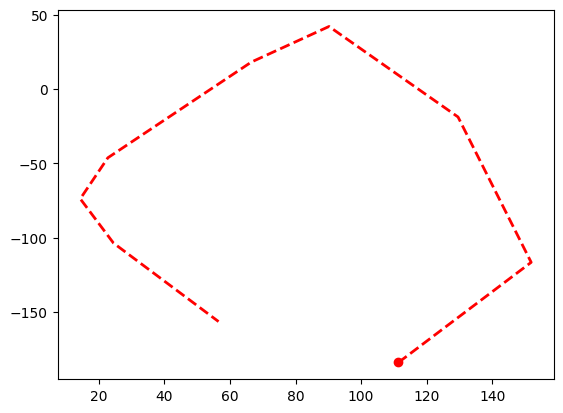

In [28]:
plt.plot(l1[hull.vertices,0], l1[hull.vertices,1], 'r--', lw=2)
plt.plot(l1[hull.vertices[0],0], l1[hull.vertices[0],1], 'ro')
plt.show()

[[95.61114691615208, 42.33188728571807], [99.00176046859116, 35.27823112166557], [109.39528176679933, 20.232327621323996], [126.09276903667825, 13.988150472669426], [124.59363830121521, 27.63270736661856], [129.7634054265842, 20.56867442224204], [120.59068605404292, 5.089335149040608], [125.35875317596792, -7.507326229610098], [129.1921955510729, -9.733303014203614], [124.43626006855558, -29.590641850718207], [100.92388525212498, -41.832770008732936], [100.50225957226502, -54.00739775061455], [118.1223390494536, -66.62115094143368], [142.77122857049108, -87.2687507526163], [151.45205137131163, -117.79875697536922], [152.73300163127715, -117.55075329750572], [148.26628050017666, -104.15635655365875], [147.99238516087502, -124.83390959264995], [144.73116649491328, -132.3091587894177], [136.40023064263858, -134.76154658916255], [131.8174946552346, -123.63938969368365], [105.89264240893357, -135.92749035014526], [112.56911433339752, -153.0550680001815], [112.56911433339752, -153.0550680001

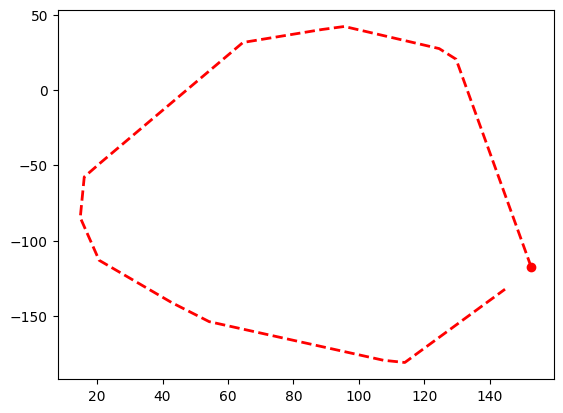

In [32]:
l1 = []
for i in point_coordinates:
    l1.append([i[0],i[1]])
print(l1)
hull = ConvexHull(np.array(l1))
print(hull.area)
l1= np.array(l1)
plt.plot(l1[hull.vertices,0], l1[hull.vertices,1], 'r--', lw=2)
plt.plot(l1[hull.vertices[0],0], l1[hull.vertices[0],1], 'ro')
plt.show()

In [18]:
pcdpoints.shape

(245603, 3)

In [29]:
pcdpoints = np.array(pcdtmp2.points)
l2 = []
for i in pcdpoints:
    l2.append([i[0],i[1]])
l2 = np.array(l2)

In [30]:
l2.shape

(245603, 2)

In [31]:
pcdtmp2.points[0]

array([118.0858866 , -25.32393791, 502.88233687])

In [32]:
pcdtmp2.colors[0]

array([0.2627451 , 0.43921569, 0.10980392])

In [33]:
import cv2
import matplotlib.pyplot as plt

In [49]:
imgread =cv2.imread('D:/programsX64/AnacondaFiles/Medicago-Code/hyperspectral_projection/data/hyperspec_records/2022-07-9/2021-06-10_14-02-54.png')

In [50]:
imgread.shape

(385, 500, 3)

In [51]:
imgreadtmp = imgread[:][0][:]

In [52]:
imgreadtmp.shape

(500, 3)

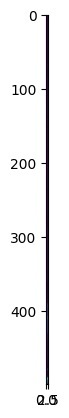

In [53]:
plt.imshow(imgreadtmp)

In [25]:
o3d.visualization.draw_geometries([pcdtmp2, hull])

In [28]:
tmp = np.array(hull.vertices)